# Tidal streams: disrupting a globular cluster

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/sgpfaff/tambora-docs/blob/master/docs/examples/04-tidal-stream.ipynb)

This is the example that exercises most of tambora at once. We take a globular
cluster, put it on an eccentric orbit in the Milky Way, let the Galactic tide
pull it apart, and then measure the stream that results.

By the end you will have:

- a **self-gravitating cluster** losing mass to a realistic Galactic potential,
- a full **stripping history** — which star left the progenitor, and when,
- the stream in **configuration space** and in **integrals-of-motion space**,
- an **animation** of the tails peeling off in the progenitor's frame,
- and a **conservation check** that says whether to believe any of it.

**The physics, briefly.** A cluster on an eccentric orbit is squeezed hardest at
pericentre, where its tidal radius
$r_t \simeq r_p\,[m/(3M_{\rm enc})]^{1/3}$ shrinks below its own size. Stars near
the two Lagrange points leak out carrying a small energy offset from the
progenitor: those pushed to slightly *lower* energy fall inward and run *ahead*
(the leading tail), those pushed *higher* drift outward and lag *behind* (the
trailing tail). The result is a thin stream tracing the progenitor's orbit, with
the most recently stripped stars nearest the remnant.

**Runtime.** About four minutes on a laptop at the default settings
(5000 particles, 30 000 steps). Set `QUICK = True` below for a ~40 s version
that shows the same physics at lower resolution.

## Setup

On Colab, uncomment and run the install cell. Locally, skip it if you already
have tambora and galpy.

In [1]:
# Colab / fresh environment only:
%pip install --pre --quiet "tambora==0.1.0a1" galpy astropy matplotlib

Note: you may need to restart the kernel to use updated packages.


In [2]:
import time

import astropy.units as u
import matplotlib.pyplot as plt
import numpy as np
from galpy.orbit import Orbit
from galpy.potential import MWPotential2014, mass
from galpy.util.conversion import mass_in_msol

import tambora
from tambora.dynamics.hooks import BoundednessHook
from tambora.simulation import Sim
from tambora.tools import mkPlummer_galpy
from tambora.tools.util.units import G_INTERNAL, KPCGYR_TO_KMS

print("tambora", tambora.__version__)

# House style for every figure in these docs.
try:
    plt.style.use("../_static/tambora.mplstyle")
except OSError:
    pass

np.random.seed(7)

QUICK = False  # True -> 2000 particles, 1.5 Gyr

tambora 0.1.0a1


## 1. Choose an orbit

We want an orbit that comes close enough to the Galactic centre to strip the
cluster, but stays far enough out that the stream is not immediately scrambled.
A pericentre near 5–6 kpc works well.

> **Careful with units.** galpy's `Orbit` uses *natural units* unless you pass
> astropy quantities. `Orbit([12.0, 0.0, 1.05, 0.0, 40.0, 0.0])` means
> $R = 12 \times 8\,$kpc $= 96$ kpc, not 12 kpc. Always attach units.

In [3]:
o = Orbit(
    [
        12.0 * u.kpc,  # R
        0.0 * u.km / u.s,  # vR
        140.0 * u.km / u.s,  # vT
        0.0 * u.kpc,  # z
        20.0 * u.km / u.s,  # vz
        0.0 * u.deg,  # phi
    ]
)
o.turn_physical_on()
o.integrate(np.linspace(0, 3, 3000) * u.Gyr, MWPotential2014)

print(f"pericentre    {o.rperi():.2f} kpc")
print(f"apocentre     {o.rap():.2f} kpc")
print(f"eccentricity  {o.e():.2f}")
print(f"radial period {o.Tr():.3f} Gyr  ->  {3 / o.Tr():.1f} orbits in 3 Gyr")

center_pos = np.array([o.x(), o.y(), o.z()])  # kpc
center_vel = np.array([o.vx(), o.vy(), o.vz()])  # km/s

pericentre    5.48 kpc
apocentre     12.00 kpc
eccentricity  0.37
radial period 0.186 Gyr  ->  16.1 orbits in 3 Gyr


## 2. Size the cluster against its tidal radius

This step decides whether you get a stream, a puff of dust, or nothing at all.
Compare the cluster's scale radius $b$ with the tidal radius at pericentre,

$$ r_t \simeq r_p \left(\frac{m}{3\,M_{\rm enc}(r_p)}\right)^{1/3}. $$

- $b \gtrsim r_t$ — the cluster dissolves within an orbit or two.
- $b \sim r_t/3$ — steady stripping with a surviving progenitor. **What we want.**
- $b \lll r_t$ — nothing happens on a useful timescale.

In [4]:
M_GC = 3e4  # cluster mass [Msun]
rp = o.rperi()

M_enc = mass(MWPotential2014, rp / 8.0) * mass_in_msol(220.0, 8.0)
r_t = rp * (M_GC / (3 * M_enc)) ** (1 / 3)

print(f"M_enc(<{rp:.1f} kpc)        = {M_enc:.2e} Msun")
print(f"tidal radius at pericentre = {r_t * 1000:.1f} pc")

B_GC = 0.008  # Plummer scale radius [kpc] = 8 pc
print(f"chosen b = {B_GC * 1000:.0f} pc  ->  b / r_t = {B_GC / r_t:.2f}")

M_enc(<5.5 kpc)        = 5.68e+10 Msun
tidal radius at pericentre = 30.7 pc
chosen b = 8 pc  ->  b / r_t = 0.26


## 3. Sample the cluster and build the simulation

`mkPlummer_galpy` samples an isotropic Plummer sphere from galpy's distribution
function and returns `(pos, vel, mass)` in tambora's user units — kpc, km/s and
M☉. The `center_pos` / `center_vel` arguments shift the sampled centre of mass
onto the orbit *exactly*, so sampling noise does not perturb the orbit we chose.

In [5]:
N = 2000 if QUICK else 5000
EPS = 0.002  # softening [kpc] = 2 pc, about b/4

pos, vel, mass_arr = mkPlummer_galpy(
    m=M_GC, b=B_GC, n=N, center_pos=center_pos, center_vel=center_vel
)

print("pos", pos.shape, "vel", vel.shape, "mass", mass_arr.shape)
print(f"particle mass          = {mass_arr[0]:.2f} Msun")
print(f"COM offset from target = {np.linalg.norm(pos.mean(0) - center_pos):.2e} kpc")

pos (5000, 3) vel (5000, 3) mass (5000,)
particle mass          = 6.00 Msun
COM offset from target = 5.86e-04 kpc


### Attach a boundedness hook

A `BoundednessHook` runs *during* the integration. At every output step it
solves for which particles are still self-bound — iterative unbinding in the
cluster's own frame — and records only the *changes*. That transition log is
what lets us ask afterwards exactly when each star was released, which you
cannot cheaply reconstruct from saved snapshots.

We also track the bound centre of mass and the velocity dispersion.

In [6]:
sim = Sim()
sim.add_particles("gc", pos, vel, mass_arr)
sim.add_external_pot(MWPotential2014)

bh = BoundednessHook(
    "gc",
    eps=EPS,
    track=("com", "com_vel", "dispersion"),
    capture_transitions=("pos",),  # remember where each star was when released
)
sim.add_hook(bh)

print(sim.components)

/private/tmp/claude-501/-Users-gabrielpfaffman-Repos-tambora/decd93ff-afda-4cd0-b6f6-b9c841213bb2/scratchpad/venv-alpha/lib/python3.13/site-packages/tambora/tools/util/_galpy_bridge.py:208: UserWarning: The provided galpy object does not have physical units explicitly set. Using galpy defaults (ro=8.0 kpc, vo=220.0 km/s). Set them explicitly with turn_physical_on(ro=..., vo=...)
  warnings.warn(

(Component('gc', 5000 particles, 3.00e+04 Msun),)


## 4. Run

Two constraints set `dt`:

1. It must resolve the cluster's internal dynamical time,
   $t_{\rm dyn} \sim \sqrt{b^3 / Gm}$.
2. `dt_out` must be an **exact** multiple of `dt`, or `run()` refuses.

A `ConservationMonitor` is attached automatically, so the progress bar shows a
live energy drift and `sim.monitor` holds the history afterwards.

In [7]:
t_dyn = np.sqrt(B_GC**3 / (G_INTERNAL * M_GC))
print(f"internal dynamical time ~ {t_dyn * 1000:.2f} Myr")

T_END = 1.5 if QUICK else 3.0
DT = 2e-4 if QUICK else 1e-4
DT_OUT = 1e-2

print(f"dt = {DT * 1000:.2f} Myr  ({t_dyn / DT:.0f} steps per dynamical time)")
print(f"{round(T_END / DT)} steps, {round(T_END / DT_OUT) + 1} snapshots")

t0 = time.time()
sim.run(t_end=T_END, dt=DT, dt_out=DT_OUT, eps=EPS, theta=0.6)
print(f"\nruntime {time.time() - t0:.0f} s")

internal dynamical time ~ 1.95 Myr
dt = 0.10 Myr  (19 steps per dynamical time)
30000 steps, 301 snapshots


  0%|          | 0/30000 [00:00<?, ?it/s]

  0%|          | 11/30000 [00:00<04:38, 107.73it/s, n_bound(gc)=4964, |dE/E0|=0.00e+00]

  0%|          | 25/30000 [00:00<04:01, 123.89it/s, n_bound(gc)=4964, |dE/E0|=0.00e+00]

  0%|          | 39/30000 [00:00<03:54, 127.95it/s, n_bound(gc)=4964, |dE/E0|=0.00e+00]

...

100%|█████████▉| 29955/30000 [04:10<00:00, 153.79it/s, n_bound(gc)=2957, |dE/E0|=2.94e-08]

100%|█████████▉| 29971/30000 [04:10<00:00, 153.56it/s, n_bound(gc)=2957, |dE/E0|=2.94e-08]

100%|█████████▉| 29987/30000 [04:10<00:00, 154.35it/s, n_bound(gc)=2957, |dE/E0|=2.94e-08]

100%|██████████| 30000/30000 [04:10<00:00, 119.65it/s, n_bound(gc)=2955, |dE/E0|=1.46e-08]


runtime 251 s


## 5. Did it conserve energy?

Always the first question. If this number is bad, nothing below is worth
looking at.

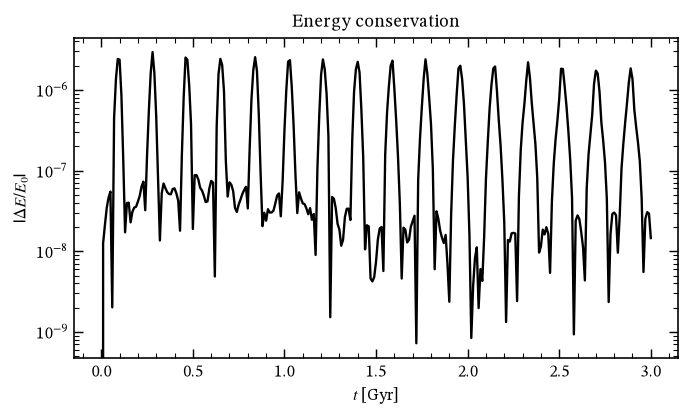

final |dE/E0| = 1.46e-08   max = 2.95e-06


In [8]:
drift = np.asarray(sim.monitor.drift["energy"])

fig, ax = plt.subplots(figsize=(6, 3.2))
ax.plot(sim.monitor.t, drift, c="k")
ax.set_yscale("log")
ax.set_xlabel("$t$ [Gyr]")
ax.set_ylabel(r"$|\Delta E / E_0|$")
ax.set_title("Energy conservation")
plt.show()

print(f"final |dE/E0| = {drift[-1]:.2e}   max = {drift.max():.2e}")

The spikes are pericentre passages: the cluster is deepest in the external
potential and moving fastest, so the leapfrog error peaks there. The drift
oscillates rather than growing — the signature of a symplectic integrator.
Staying below $\sim10^{-6}$ over 16 orbits is healthy.

## 6. The stream

Black is still bound, orange has been stripped.

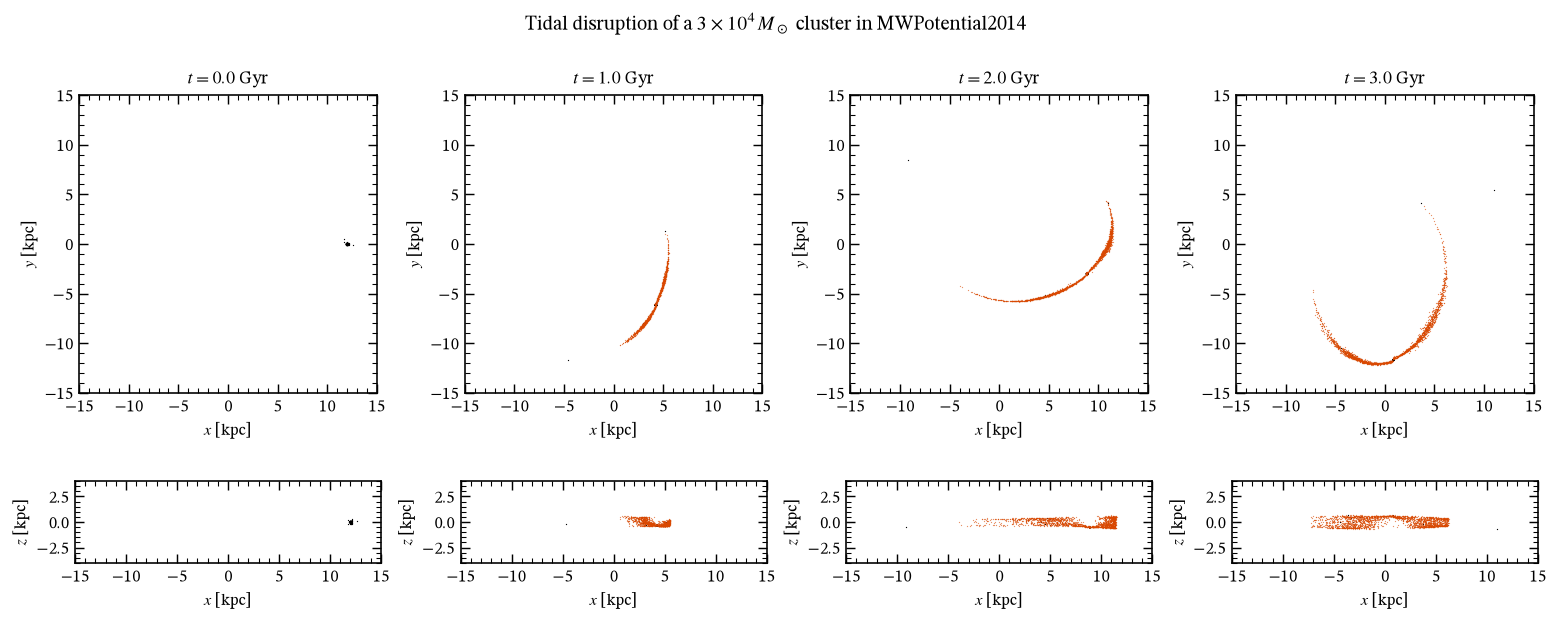

In [9]:
frac = bh.fraction()
rel = bh.release_time()  # nan = still bound, else time of release

snaps = [0, len(sim.times) // 3, 2 * len(sim.times) // 3, len(sim.times) - 1]

fig, axes = plt.subplots(2, 4, figsize=(12, 5.2))
for j, si in enumerate(snaps):
    x, y, z = sim.gc.x(t=si), sim.gc.y(t=si), sim.gc.z(t=si)
    stripped = np.isfinite(bh.release_time(sim.times[si]))
    for row, (a, b, lab, half) in enumerate(
        [(x, y, ("x", "y"), 15), (x, z, ("x", "z"), 4)]
    ):
        ax = axes[row, j]
        ax.scatter(a[~stripped], b[~stripped], s=0.5, lw=0, c="k", rasterized=True)
        ax.scatter(
            a[stripped], b[stripped], s=0.5, lw=0, c="#d94801", alpha=0.6,
            rasterized=True,
        )
        ax.set_xlim(-15, 15)
        ax.set_ylim(-half, half)
        ax.set_aspect("equal")
        ax.set_xlabel(f"${lab[0]}$ [kpc]")
        ax.set_ylabel(f"${lab[1]}$ [kpc]")
        if row == 0:
            ax.set_title(f"$t = {sim.times[si]:.1f}$ Gyr")
fig.suptitle(
    r"Tidal disruption of a $3\times10^{4}\,M_\odot$ cluster in MWPotential2014",
    y=1.0,
)
fig.tight_layout()
plt.show()

## 7. Stripping time — the stream's clock

`release_time()` returns, for every particle, the time it most recently became
unbound (`nan` if still bound). Colouring the stream by it makes the structure
obvious: recently stripped stars sit near the progenitor, and the ends of the
tails are the oldest escapees.

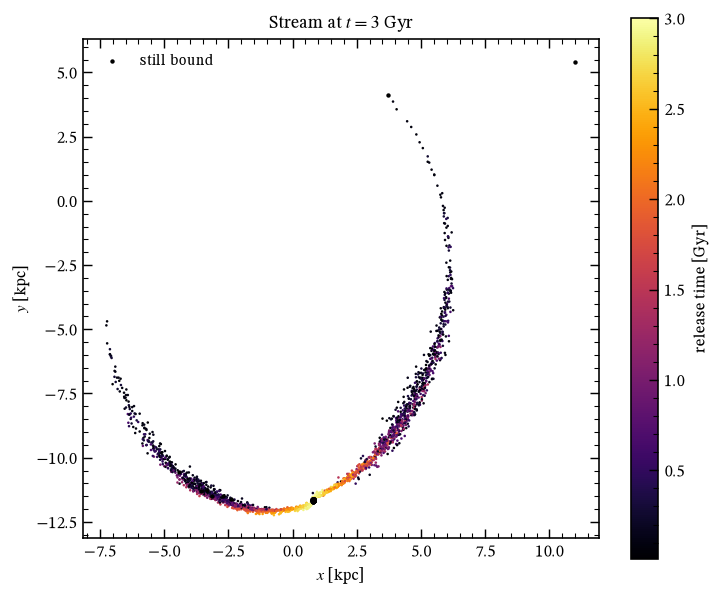

In [10]:
xf, yf = sim.gc.x(t=-1), sim.gc.y(t=-1)
bound_f = ~np.isfinite(rel)

fig, ax = plt.subplots(figsize=(6.4, 5.4))
sc = ax.scatter(xf, yf, c=rel, s=2.0, lw=0, cmap="inferno", rasterized=True)
ax.scatter(xf[bound_f], yf[bound_f], s=6, lw=0, c="k", label="still bound")
ax.set_xlabel("$x$ [kpc]")
ax.set_ylabel("$y$ [kpc]")
ax.set_aspect("equal")
ax.legend(loc="upper left")
ax.set_title(f"Stream at $t = {sim.times[-1]:.0f}$ Gyr")
plt.colorbar(sc, ax=ax, label="release time [Gyr]")
plt.show()

## 8. Integrals of motion: the $\Delta E$–$\Delta L_z$ plane

Configuration space shows you a stream; **integral space shows you why it is a
stream.** Stripped stars carry a small, nearly constant offset in energy and
angular momentum from the progenitor, set by where on the tidal boundary they
escaped. The leading and trailing tails separate into two lobes.

We use *specific* quantities (per unit mass), measured relative to the bound
remnant.

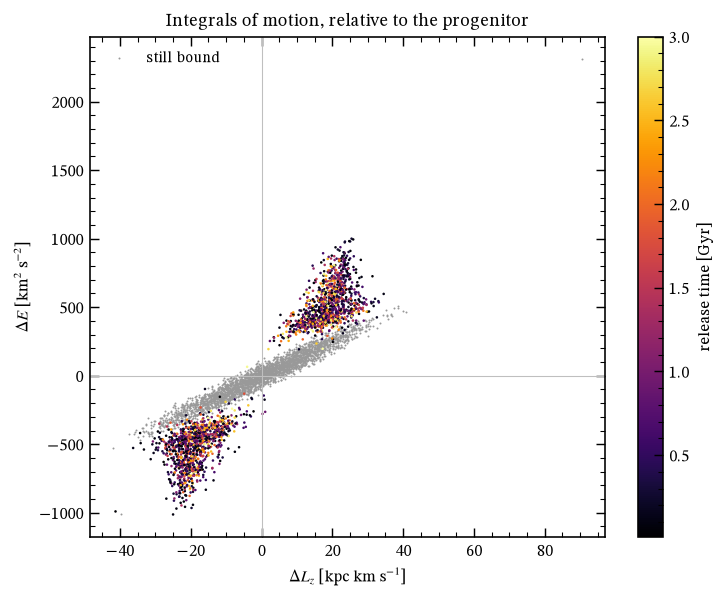

In [11]:
E = sim.gc.energy(t=-1) / sim.gc.mass  # specific energy [km^2/s^2]
Lz = sim.gc.Lz(t=-1) / sim.gc.mass  # specific L_z      [kpc km/s]

E0, Lz0 = E[bound_f].mean(), Lz[bound_f].mean()
dE, dLz = E - E0, Lz - Lz0

fig, ax = plt.subplots(figsize=(6.4, 5.0))
ax.scatter(
    dLz[bound_f], dE[bound_f], s=1.2, lw=0, c="0.6", label="still bound",
    rasterized=True,
)
sc = ax.scatter(
    dLz[~bound_f], dE[~bound_f], c=rel[~bound_f], s=2.0, lw=0, cmap="inferno",
    rasterized=True,
)
ax.axhline(0, lw=0.6, c="0.75")
ax.axvline(0, lw=0.6, c="0.75")
ax.set_xlabel(r"$\Delta L_z$ [kpc km s$^{-1}$]")
ax.set_ylabel(r"$\Delta E$ [km$^2$ s$^{-2}$]")
ax.set_title("Integrals of motion, relative to the progenitor")
ax.legend(loc="upper left")
plt.colorbar(sc, ax=ax, label="release time [Gyr]")
plt.show()

Stars with $\Delta E < 0$ are on tighter, shorter-period orbits: they run ahead
of the progenitor and form the **leading** tail. Stars with $\Delta E > 0$ lag
behind into the **trailing** tail. That gives a clean way to label them.

leading  tail:   997 stars
trailing tail:  1040 stars
still bound:    2963 stars


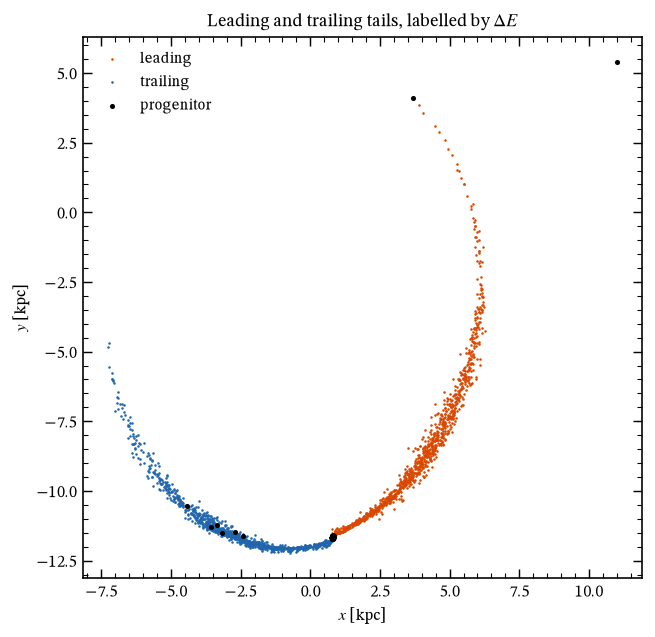

In [12]:
leading = (dE < 0) & ~bound_f
trailing = (dE > 0) & ~bound_f
print(f"leading  tail: {leading.sum():5d} stars")
print(f"trailing tail: {trailing.sum():5d} stars")
print(f"still bound:   {bound_f.sum():5d} stars")

fig, ax = plt.subplots(figsize=(6.4, 5.4))
ax.scatter(xf[leading], yf[leading], s=2, lw=0, c="#d94801", label="leading")
ax.scatter(xf[trailing], yf[trailing], s=2, lw=0, c="#2166ac", label="trailing")
ax.scatter(xf[bound_f], yf[bound_f], s=8, lw=0, c="k", label="progenitor")
ax.set_xlabel("$x$ [kpc]")
ax.set_ylabel("$y$ [kpc]")
ax.set_aspect("equal")
ax.legend(loc="upper left")
ax.set_title(r"Leading and trailing tails, labelled by $\Delta E$")
plt.show()

## 9. Mass loss

`fraction()` is derived from the transition log rather than stored per
snapshot, so it costs nothing extra to record. The steps line up with
pericentre passages.

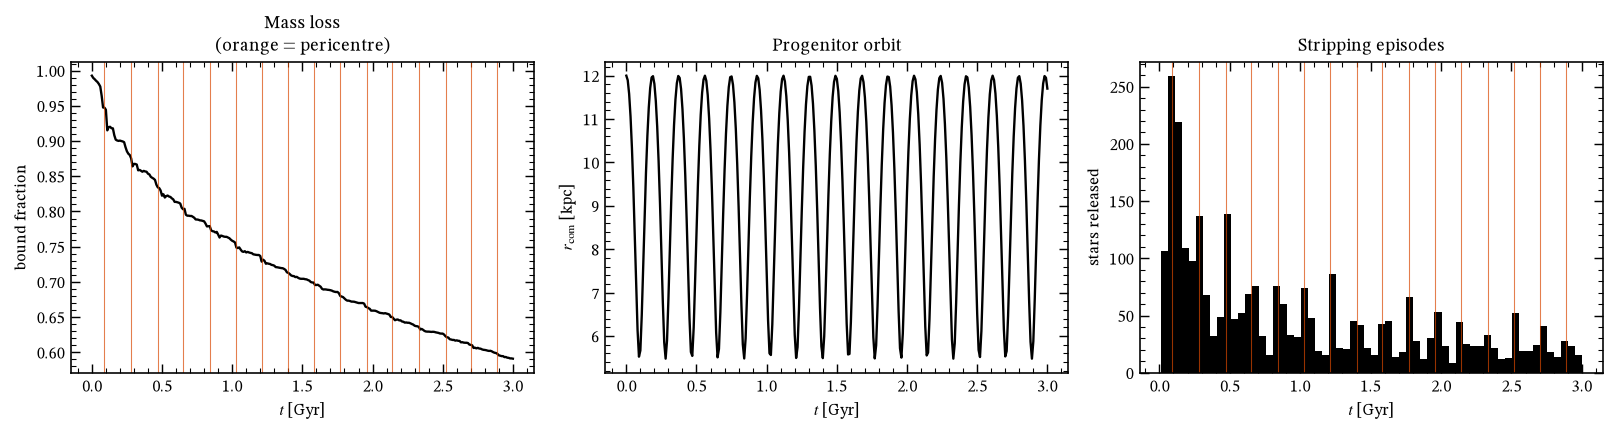

bound fraction at t = 3 Gyr: 0.591
mass lost: 1.23e+04 Msun


In [13]:
rcom = np.linalg.norm(np.asarray(bh.com), axis=-1)
bt = np.asarray(bh.t)
peri = bt[1:-1][(rcom[1:-1] < rcom[:-2]) & (rcom[1:-1] < rcom[2:])]

fig, ax = plt.subplots(1, 3, figsize=(12.5, 3.4))

ax[0].plot(bh.t, frac, c="k")
for p in peri:
    ax[0].axvline(p, c="#d94801", lw=0.6, alpha=0.7)
ax[0].set_xlabel("$t$ [Gyr]")
ax[0].set_ylabel("bound fraction")
ax[0].set_title("Mass loss\n(orange = pericentre)")

ax[1].plot(bh.t, rcom, c="k")
ax[1].set_xlabel("$t$ [Gyr]")
ax[1].set_ylabel(r"$r_{\rm com}$ [kpc]")
ax[1].set_title("Progenitor orbit")

ax[2].hist(bh.transition_times("unbound"), bins=60, color="k")
for p in peri:
    ax[2].axvline(p, c="#d94801", lw=0.6, alpha=0.7)
ax[2].set_xlabel("$t$ [Gyr]")
ax[2].set_ylabel("stars released")
ax[2].set_title("Stripping episodes")

fig.tight_layout()
plt.show()

print(f"bound fraction at t = {sim.times[-1]:.0f} Gyr: {frac[-1]:.3f}")
print(f"mass lost: {(1 - frac[-1]) * M_GC:.3g} Msun")

The histogram is the clearest statement of the physics: stripping is not
continuous, it happens in bursts at pericentre. The
[stripping analysis notebook](05-tidal-stripping.ipynb) takes this much further.

## 10. The progenitor's velocity dispersion

`track=("dispersion",)` recorded the mass-weighted 3D velocity dispersion of
the bound remnant at every fire. As the cluster loses mass it also cools.

> **Units.** Hook quantities are in tambora's **internal** units (kpc/Gyr for
> velocity), not the km/s the `Sim`/`Component` accessors return. Hooks run
> inside the integrator's hot loop, where converting on every fire would be
> wasted work. Multiply by `KPCGYR_TO_KMS`.

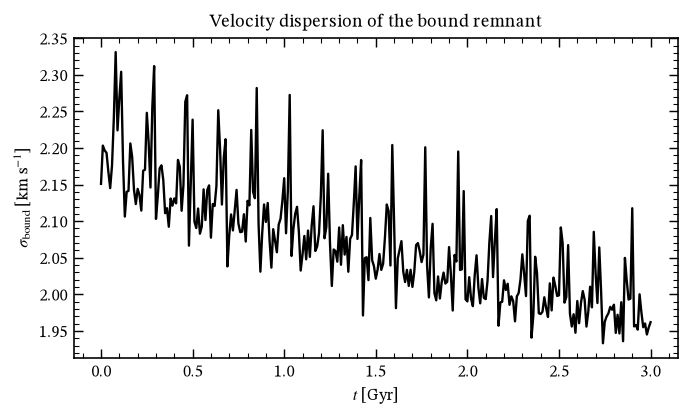

In [14]:
fig, ax = plt.subplots(figsize=(6, 3.2))
ax.plot(bh.t, np.asarray(bh.dispersion) * KPCGYR_TO_KMS, c="k")
ax.set_xlabel("$t$ [Gyr]")
ax.set_ylabel(r"$\sigma_{\rm bound}$ [km s$^{-1}$]")
ax.set_title("Velocity dispersion of the bound remnant")
plt.show()

## 11. Animate it

The clearest view is the progenitor's own frame: subtract the bound centre of
mass and watch the tails peel away, with the mass-loss curve filling in beside
it.

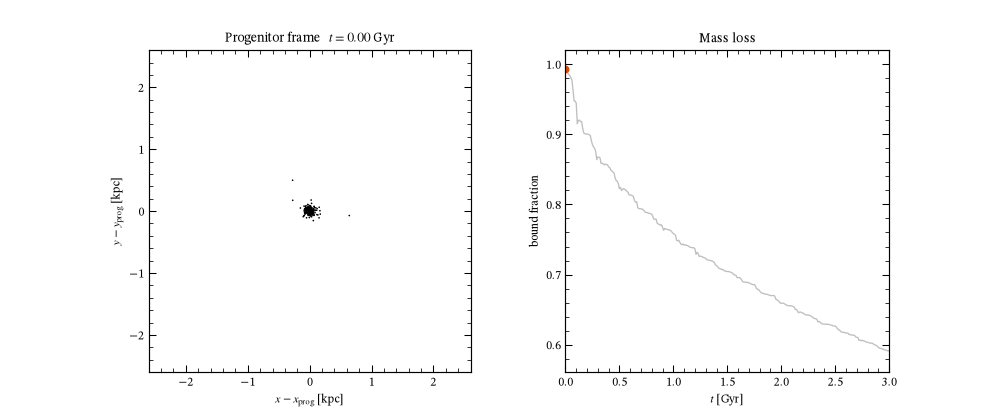

In [15]:
from matplotlib.animation import FuncAnimation, PillowWriter  # noqa: E402
from IPython.display import Image  # noqa: E402

com = np.asarray(bh.com)
frames = range(0, len(sim.times), 2)
pos_all = sim.pos()

fig, (a0, a1) = plt.subplots(
    1, 2, figsize=(10.4, 4.4), gridspec_kw={"width_ratios": [1.15, 1]}
)

scat = a0.scatter([], [], s=1.6, lw=0)
a0.set_xlim(-2.6, 2.6)
a0.set_ylim(-2.6, 2.6)
a0.set_aspect("equal")
a0.set_xlabel(r"$x - x_{\rm prog}$ [kpc]")
a0.set_ylabel(r"$y - y_{\rm prog}$ [kpc]")
title = a0.set_title("")

a1.plot(bh.t, frac, c="0.75", lw=1.0)
(line,) = a1.plot([], [], c="k", lw=1.6)
(dot,) = a1.plot([], [], "o", c="#d94801", ms=5)
a1.set_xlim(0, bh.t[-1])
a1.set_ylim(min(frac) - 0.03, 1.02)
a1.set_xlabel("$t$ [Gyr]")
a1.set_ylabel("bound fraction")
a1.set_title("Mass loss")


def update(i):
    j = min(i, len(com) - 1)
    scat.set_offsets(pos_all[i, :, :2] - com[j, :2])
    stripped = np.isfinite(bh.release_time(sim.times[i]))
    scat.set_color(np.where(stripped, "#d94801", "k"))
    title.set_text(f"Progenitor frame   $t = {sim.times[i]:.2f}$ Gyr")
    line.set_data(bh.t[: j + 1], frac[: j + 1])
    dot.set_data([bh.t[j]], [frac[j]])
    return scat, line, dot, title


anim = FuncAnimation(fig, update, frames=frames, blit=False)
anim.save("stream_progenitor.gif", writer=PillowWriter(fps=8), dpi=95)
plt.close(fig)

Image(filename="stream_progenitor.gif")

## Where to go next

Directly building on this run:

- [Tidal stripping analysis](05-tidal-stripping.ipynb) — where and when stars
  actually escape, with the Roche potential drawn underneath.
- [Stream tracks and observables](06-stream-track.ipynb) — fit the stream with
  galpy's `StreamTrack` and get sky coordinates, width and linear density.
- [Subhalo impacts and stream gaps](07-stream-gaps.ipynb) — fly a dark subhalo
  through the stream and check the kick against theory.

Things to try by changing this notebook:

- **A different orbit.** Drop `vT` to 100 km/s for a more radial orbit and much
  faster disruption; raise it to 180 for a nearly circular one where the cluster
  barely notices.
- **A different concentration.** `B_GC = 0.02` dissolves the cluster completely
  within about a gigayear; `B_GC = 0.004` keeps it nearly intact.
- **No self-gravity.** Pass `method=None` to `run()` (and drop `eps`). The
  tails still form — tides do that — but the progenitor no longer holds itself
  together, which shows exactly what self-gravity is buying you.

## Related

- [Hooks](../guide/hooks.md) — everything `BoundednessHook` can tell you
- [External forces](../guide/external-forces.md) — composing galpy potentials
- [Reliable N-body simulations](../guide/reliable-nbody.md) — choosing `dt` and `eps`